In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
import pandas as pd 
import numpy as np 


In [3]:
df=pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [5]:
categorical_df = df.select_dtypes(include=['object', 'category'])
categorical_df

,gender,stress_level,academic_work_impact
0,Male,Medium,No
1,Female,Medium,No
2,Female,Low,Yes
3,Other,Low,NaN
4,Female,Medium,No
...,...,...,...
691364,Male,NaN,No
691365,Female,High,No
691366,Other,Medium,No
691367,Other,NaN,NaN


In [6]:
integer_df = df.select_dtypes(include=['int64', 'float64'])
integer_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1
...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,1


In [7]:
integer_df["age"].unique()

array([24., 19., 18., 21., 26., 28., 25., 20., 34., 30., 29., 27., 22.,
       32., 35., nan, 31., 23., 33.])

In [8]:
integer_df["age"].isnull().sum()

np.int64(28929)

26.61540818791136


<Axes: >

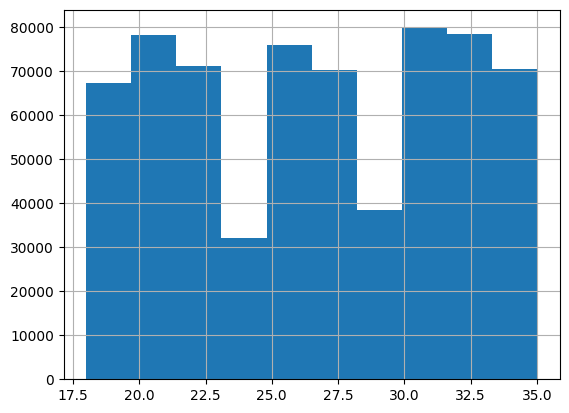

In [9]:
print(integer_df["age"].mean())
df['age'].describe()
df['age'].hist()

In [10]:
df['age'].median()

27.0

In [11]:
from sklearn.impute import SimpleImputer

num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
            'work_study_hours', 'sleep_hours', 'notifications_per_day',
            'app_opens_per_day', 'weekend_screen_time']

imputer = SimpleImputer(strategy='median')
integer_df[num_cols] = imputer.fit_transform(integer_df[num_cols])
integer_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
0,0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1
1,1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,0
2,2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,1
...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1
691366,691366,27.0,7.77,2.31,1.33,2.06,6.16,150.0,86.0,7.79,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,1


In [12]:
categorical_df.isnull().sum()


gender                  29034
stress_level            55148
academic_work_impact    44224
dtype: int64

In [13]:
categorical_df["gender"].unique()

array(['Male', 'Female', 'Other', nan], dtype=object)

In [14]:
categorical_df['gender'] = categorical_df['gender'].fillna('Unknown')

In [15]:
categorical_df['gender'].unique()
categorical_df['stress_level'].value_counts()

stress_level
High      220873
Low       207783
Medium    207565
Name: count, dtype: int64

In [16]:
categorical_df['stress_level'].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [17]:
categorical_df['stress_level'].isnull().sum()

np.int64(55148)

In [18]:
mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

categorical_df['stress_level_num'] = categorical_df['stress_level'].map(mapping)

mean = categorical_df['stress_level_num'].median()

categorical_df['stress_level_num'] = categorical_df['stress_level_num'].fillna(mean)
categorical_df['stress_level_num'].unique()

array([2., 1., 3.])

In [19]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [20]:
df.groupby('academic_work_impact')[['academic_work_impact','work_study_hours']]

In [21]:
output = df[["age" ,'academic_work_impact']].sort_values('age').reset_index(drop=True)
print(output)

         age academic_work_impact
0       18.0                  NaN
1       18.0                   No
2       18.0                   No
3       18.0                  NaN
4       18.0                   No
...      ...                  ...
691364   NaN                  Yes
691365   NaN                   No
691366   NaN                   No
691367   NaN                  Yes
691368   NaN                   No

[691369 rows x 2 columns]


In [22]:
output = df[['sleep_hours', 'academic_work_impact']]
print(output)

        sleep_hours academic_work_impact
0              7.46                   No
1              8.22                   No
2              6.25                  Yes
3              8.85                  NaN
4              5.25                   No
...             ...                  ...
691364         7.71                   No
691365         6.59                   No
691366         6.16                   No
691367         5.53                  NaN
691368         4.91                  Yes

[691369 rows x 2 columns]


In [23]:
df.groupby('academic_work_impact')[['daily_screen_time_hours', 'social_media_hours', 
                                      'sleep_hours', 'stress_level']].mean(numeric_only=True)

,daily_screen_time_hours,social_media_hours,sleep_hours
academic_work_impact,,,
No,7.656043,2.463675,6.810887
Yes,7.624069,2.478379,6.797887


In [24]:
categorical_df['academic_work_impact'] = categorical_df['academic_work_impact'].fillna('Unknown')
categorical_df

,gender,stress_level,academic_work_impact,stress_level_num
0,Male,Medium,No,2.0
1,Female,Medium,No,2.0
2,Female,Low,Yes,1.0
3,Other,Low,Unknown,1.0
4,Female,Medium,No,2.0
...,...,...,...,...
691364,Male,NaN,No,2.0
691365,Female,High,No,3.0
691366,Other,Medium,No,2.0
691367,Other,NaN,Unknown,2.0


In [25]:
categorical_df = categorical_df.drop("stress_level", axis=1)


In [26]:
categorical_df 

,gender,academic_work_impact,stress_level_num
0,Male,No,2.0
1,Female,No,2.0
2,Female,Yes,1.0
3,Other,Unknown,1.0
4,Female,No,2.0
...,...,...,...
691364,Male,No,2.0
691365,Female,No,3.0
691366,Other,No,2.0
691367,Other,Unknown,2.0


In [27]:
categorical_df = pd.get_dummies(categorical_df, columns=['gender', 'academic_work_impact'], drop_first=False)


In [28]:

bool_cols = categorical_df.select_dtypes(include='bool').columns
categorical_df[bool_cols] = categorical_df[bool_cols].astype(int)
categorical_df

,stress_level_num,gender_Female,gender_Male,gender_Other,gender_Unknown,academic_work_impact_No,academic_work_impact_Unknown,academic_work_impact_Yes
0,2.0,0,1,0,0,1,0,0
1,2.0,1,0,0,0,1,0,0
2,1.0,1,0,0,0,0,0,1
3,1.0,0,0,1,0,0,1,0
4,2.0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...
691364,2.0,0,1,0,0,1,0,0
691365,3.0,1,0,0,0,1,0,0
691366,2.0,0,0,1,0,1,0,0
691367,2.0,0,0,1,0,0,1,0


In [29]:
integer_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
0,0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1
1,1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,0
2,2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,1
...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1
691366,691366,27.0,7.77,2.31,1.33,2.06,6.16,150.0,86.0,7.79,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,1


In [30]:
integer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      691369 non-null  float64
 2   daily_screen_time_hours  691369 non-null  float64
 3   social_media_hours       691369 non-null  float64
 4   gaming_hours             691369 non-null  float64
 5   work_study_hours         691369 non-null  float64
 6   sleep_hours              691369 non-null  float64
 7   notifications_per_day    691369 non-null  float64
 8   app_opens_per_day        691369 non-null  float64
 9   weekend_screen_time      691369 non-null  float64
 10  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 58.0 MB


In [31]:
final_df = pd.concat([categorical_df, integer_df], axis=1)
print(final_df.shape)
final_df.head()

(691369, 19)


,stress_level_num,gender_Female,gender_Male,gender_Other,gender_Unknown,academic_work_impact_No,academic_work_impact_Unknown,academic_work_impact_Yes,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
0,2.0,0,1,0,0,1,0,0,0,24.0,7.77,1.83,1.59,2.11,7.46,122.0,38.0,8.63,1
1,2.0,1,0,0,0,1,0,0,1,19.0,5.97,1.08,1.33,3.03,8.22,76.0,19.0,9.58,0
2,1.0,1,0,0,0,0,0,1,2,18.0,5.09,2.31,1.33,2.20,6.25,134.0,60.0,7.47,0
3,1.0,0,0,1,0,0,1,0,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,1
4,2.0,1,0,0,0,1,0,0,4,26.0,11.20,1.87,2.81,1.95,5.25,150.0,104.0,13.39,1


In [32]:
x=final_df.drop("addicted_label",axis=1)
y=final_df["addicted_label"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2)

In [33]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='auc',
    random_state=42
)
clf.fit(X_train, y_train)

y_probs = clf.predict_proba(X_test)[:, 1]


In [34]:
y_probs = clf.predict_proba(X_test)
y_probs_positive = y_probs[:, 1]
from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_test, y_probs_positive)
print(score)

0.9538541738799879


In [35]:
test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

In [36]:
test_df[num_cols] = imputer.transform(test_df[num_cols])  # pas fit_transform !
test_df[num_cols]

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
0,30.0,9.34,2.31,0.77,4.09,7.15,153.0,16.0,9.58
1,27.0,7.77,1.91,1.33,1.20,8.67,239.0,148.0,10.68
2,26.0,8.48,3.64,1.33,3.39,7.47,106.0,123.0,9.58
3,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88
4,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72
...,...,...,...,...,...,...,...,...,...
296297,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10
296298,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25
296299,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57
296300,27.0,7.77,1.25,0.52,0.71,6.27,57.0,38.0,7.19


In [37]:
# Séparer comme sur train
test_categorical = test_df.select_dtypes(include=['object', 'category'])
test_integer = test_df.select_dtypes(include=['int64', 'float64'])

# Imputation numérique (transform, pas fit_transform)
test_integer[num_cols] = imputer.transform(test_integer[num_cols])

# Categorielles
test_categorical['gender'] = test_categorical['gender'].fillna('Unknown')
test_categorical['academic_work_impact'] = test_categorical['academic_work_impact'].fillna('Unknown')
test_categorical['stress_level_num'] = test_categorical['stress_level'].map(mapping)
test_categorical['stress_level_num'] = test_categorical['stress_level_num'].fillna(mean)
test_categorical = test_categorical.drop('stress_level', axis=1)

test_categorical = pd.get_dummies(test_categorical, columns=['gender', 'academic_work_impact'], drop_first=False)
bool_cols = test_categorical.select_dtypes(include='bool').columns
test_categorical[bool_cols] = test_categorical[bool_cols].astype(int)

test_final = pd.concat([test_categorical, test_integer], axis=1)

# Vérifier alignement des colonnes avec X_train
test_final = test_final.reindex(columns=x.columns, fill_value=0)

# Prédire
test_probs = clf.predict_proba(test_final)[:, 1]

# Soumission
submission = pd.DataFrame({'id': test_df['id'], 'addicted_label': test_probs})
submission.to_csv('submission.csv', index=False)

In [38]:
print(submission.shape)
print(submission.head())
print(submission['addicted_label'].describe())  # vérifier que les valeurs sont bien entre 0 et 1

(296302, 2)
       id  addicted_label
0  691369        0.997342
1  691370        0.931544
2  691371        0.962392
3  691372        0.967224
4  691373        0.996195
count    296302.000000
mean          0.708828
std           0.341936
min           0.001598
25%           0.427690
50%           0.898071
75%           0.997754
max           0.999968
Name: addicted_label, dtype: float64
